# UNet layer activation diagnostics

This notebook drives the `imp evaluate` CLI with `--save-layer`, loads the captured intermediate activations, and plots them as tiled feature-map grids. The target question is:

> **Does the UNet leverage the ERA5 data when trained with the naive linear encoder?**

The flow is:

1. Pick a config, checkpoint and a list of layer paths to hook.
2. Run `imp evaluate ... --save-layer` from a notebook cell. A PyTorch forward hook fires on each selected module during the Lightning test loop; only the **first processor rollout step** per test batch is persisted, together with a copy of the raw batch tensors (SIC, ERA5, `float_argo`, target). Flushing happens in `on_test_batch_end`.
3. Load the per-batch `.pt` files from disk and plot each layer's feature maps.

Only `test_step` is instrumented (this is what `imp evaluate` runs); `validation_step` runs during `fit`/`validate` and is not hooked here. The hook manager lives at `icenet_mp.visualisations.hook_manager.ActivationHookManager`.

## UNet pipeline shapes (config: `quick_test`, `start_out_channels=64`)

Expected tensor shapes along the `EncodeProcessDecode` → `UNetProcessor` → decoder pipeline when driven by `icenet_mp/config/sample.yaml` (which selects `model=quick_test`, 3-step history, 2-step forecast, 25 km SIC grid, 0.5° ERA5 grid). Shapes here match what the hook manager will save, i.e. an **NCHW slice** captured on the first fire of each module during the first test batch's first rollout step.

| Stage | Hook path (`processor.*` unless noted) | Saved tensor shape | Notes |
| --- | --- | --- | --- |
| SIC encoder output (one history step) | `encoder_sic_icenet` | `(N, 1, 128, 128)` | Naive bilinear resize 432 → 128; ~84 km/px latent |
| ERA5 encoder output (one history step) | `encoder_era5` | `(N, 28, 128, 128)` | 141×720 regridded to 128×128; 28 atmospheric channels |
| Concat latent (T folded into C by rollout) | *(no module; see `processor` pre-hook)* | `(N, 87, 128, 128)` | 3 history × 29 ch = 87 |
| `conv1` block (`bn1`) | `conv1` | `(N, 64, 128, 128)` | Two 3×3 convs, 87 → 64 ch |
| after `maxpool1` | `maxpool1` | `(N, 64, 64, 64)` | Stride-2 down |
| `conv2` block (`bn2`) | `conv2` | `(N, 128, 64, 64)` | 64 → 128 ch |
| after `maxpool2` | `maxpool2` | `(N, 128, 32, 32)` | |
| `conv3` block (`bn3`) | `conv3` | `(N, 256, 32, 32)` | 128 → 256 ch |
| after `maxpool3` | `maxpool3` | `(N, 256, 16, 16)` | |
| `conv4` block (`bn4`) | `conv4` | `(N, 256, 16, 16)` | 256 → 256 ch (no channel doubling in code) |
| after `maxpool4` | `maxpool4` | `(N, 256, 8, 8)` | |
| `conv5` — bottleneck (`bn5`) | `conv5` | `(N, 512, 8, 8)` | 256 → 512 ch; full-domain receptive field |
| `up6b` block | `up6b` | `(N, 256, 16, 16)` | Upsample + skip-concat `bn4` |
| `up7b` block | `up7b` | `(N, 256, 32, 32)` | Upsample + skip-concat `bn3` |
| `up8b` block | `up8b` | `(N, 128, 64, 64)` | Upsample + skip-concat `bn2` |
| `up9b` block | `up9b` | `(N, 64, 128, 128)` | Upsample + skip-concat `bn1` |
| `final_layer` (1×1 conv) | `final_layer` | `(N, C_latent_out, 128, 128)` | Per-pixel channel projection |

**Naming caveat:** inside `UNetProcessor.forward` the *variable* assigned to `maxpool1(bn1)` is called `conv1`, so the diagram's "post-`conv1` / pre-pool" tensor is accessed in code as the `self.conv1` **module's** output. For hooks, use the module names in the table above.


## 1. Parameters

Edit the values below to point at your checkpoint and the layers you want to hook. All paths are interpreted relative to the repository root unless absolute.

In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

CONFIG_NAME = "sample_reproject.local"

CHECKPOINT = (REPO_ROOT / "../base/training/wandb/run-20260505_165935-fopmt8af/checkpoints/epoch=0-step=346.ckpt").resolve()

ACTIVATIONS_DIR = (REPO_ROOT / "../base/evaluation/activations").resolve()


HYDRA_OVERRIDES = ["data=sample_reproject"]

print("REPO_ROOT       :", REPO_ROOT)
print("CONFIG_NAME     :", CONFIG_NAME)
print("CHECKPOINT      :", CHECKPOINT, "(exists:", CHECKPOINT.exists(), ")")
print("ACTIVATIONS_DIR :", ACTIVATIONS_DIR)


REPO_ROOT       : /Users/sarana/Documents/e&s/SeaIce/icenet-mp
CONFIG_NAME     : sample_reproject.local
CHECKPOINT      : /Users/sarana/Documents/e&s/SeaIce/base/training/wandb/run-20260505_165935-fopmt8af/checkpoints/epoch=0-step=346.ckpt (exists: True )
ACTIVATIONS_DIR : /Users/sarana/Documents/e&s/SeaIce/base/evaluation/activations
LAYER_PATHS     :
  - encoder_sic_icenet


## 2. Run `imp evaluate` with activation capture

The cell below invokes the CLI as a subprocess. The same command can also be pasted into a terminal (from the repo root):

```bash
imp evaluate \
  --checkpoint <CHECKPOINT> \
  --save-layer \
  ...
```

the `--save-layer` flag ensures that values for each selected layer will be saved to disk each batch. The command otherwise behaves like a normal `imp evaluate` run: it loads the checkpoint, builds the data module, and runs the Lightning test loop. Activations are saved to `${base_path}/evaluation/activations/` per default as `batch_00000.pt`, `batch_00001.pt`, ..., plus a `meta`data.json`.

In [2]:
import shlex
import subprocess

cmd: list[str] = [
    "imp", "evaluate",
    "--config-name", CONFIG_NAME,
    "--checkpoint", str(CHECKPOINT),
    "--save-layer",
]
#for layer_path in LAYER_PATHS:
#    cmd += ["--save-layer", layer_path]
cmd += HYDRA_OVERRIDES

print("$", " ".join(shlex.quote(part) for part in cmd))

result = subprocess.run(cmd, cwd=REPO_ROOT, check=False)
print(f"\nexit code: {result.returncode}")


$ imp evaluate --config-name sample_reproject.local --checkpoint '/Users/sarana/Documents/e&s/SeaIce/base/training/wandb/run-20260505_165935-fopmt8af/checkpoints/epoch=0-step=346.ckpt' --save-layer data=sample_reproject


Seed set to 555
😈 [2026-05-05 17:40:35] Loading a trained sample model...
😈 [2026-05-05 17:40:35] Found 2 dataset groups.
😈 [2026-05-05 17:40:35] 1) sic-icenet:
😈 [2026-05-05 17:40:35]    - /Users/sarana/Documents/e&s/SeaIce/base/data/anemoi/samp-sicsouth-osisaf-25k-2017-2019-24h-v1.zarr
😈 [2026-05-05 17:40:35] 2) era5:
😈 [2026-05-05 17:40:35]    - /Users/sarana/Documents/e&s/SeaIce/base/data/anemoi/samp-weathersouth-era5-25p0km-2017-2019-24h-v3.zarr
😈 [2026-05-05 17:42:36] Configuring model for evaluation.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
😈 [2026-05-05 17:42:36] Assigning 9 workers for data loading.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] L

wandb: 
wandb: 🚀 View run carbonite-nerf-herder-234 at: https://wandb.ai/turing-seaice/evaluate/runs/ira9dviw
wandb: Find logs at: ../base/training/wandb/run-20260505_174237-ira9dviw/logs

exit code: 1


## 3. Load captured activations

Each batch produces one `batch_{idx:05d}.pt` file containing:

- `batch_idx` (int)
- `activations` — `dict[layer_path, Tensor]`, one NCHW slice per layer (first rollout step only)
- `inputs` — `dict[batch_key, Tensor]` copied from the test batch (SIC, ERA5, `float_argo` if present, `target`)

In [ ]:
import json
import torch

metadata_path = ACTIVATIONS_DIR / "metadata.json"
metadata = json.loads(metadata_path.read_text())
print("metadata:", json.dumps(metadata, indent=2))

batch_files = sorted(ACTIVATIONS_DIR.glob("batch_*.pt"))
print(f"\n{len(batch_files)} batch file(s) in {ACTIVATIONS_DIR}")
for path in batch_files[:5]:
    print(f"  - {path.name}")

payload = torch.load(batch_files[0], map_location="cpu", weights_only=False)

print(f"\nbatch_idx: {payload['batch_idx']}")
print("\nactivations:")
for name, tensor in payload["activations"].items():
    print(f"  {name:30s} {tuple(tensor.shape)}  {tensor.dtype}")

print("\ninputs (raw batch tensors):")
for name, tensor in payload.get("inputs", {}).items():
    print(f"  {name:30s} {tuple(tensor.shape)}  {tensor.dtype}")


metadata: {
  "layer_paths": [
    "encoder_sic_icenet",
    "encoder_era5",
    "processor.conv1",
    "processor.conv2",
    "processor.conv3",
    "processor.conv4",
    "processor.conv5",
    "processor.up6",
    "processor.up6b",
    "processor.up7",
    "processor.up7b",
    "processor.up8",
    "processor.up8b",
    "processor.up9",
    "processor.up9b",
    "processor.final_layer"
  ],
  "save_inputs": true,
  "batch_file_template": "batch_{batch_idx:05d}.pt",
  "note": "Only activations from the first processor rollout step are saved."
}

14 batch file(s) in /Users/sarana/Documents/e&s/SeaIce/base/evaluation/activations
  - batch_00000.pt
  - batch_00001.pt
  - batch_00002.pt
  - batch_00003.pt
  - batch_00004.pt

batch_idx: 0

activations:
  encoder_sic_icenet             (2, 1, 128, 128)  torch.float32
  encoder_era5                   (2, 28, 128, 128)  torch.float32
  processor.conv1                (2, 64, 128, 128)  torch.float32
  processor.conv2                (2, 128, 6

## 4. Visualise each layer in turn

For each hooked layer, plot a tiled grid of channel feature maps from the first batch element (`N=0`). When a layer has many channels (e.g. `conv5` has 512), only the first `MAX_CHANNELS_PER_LAYER` are shown.

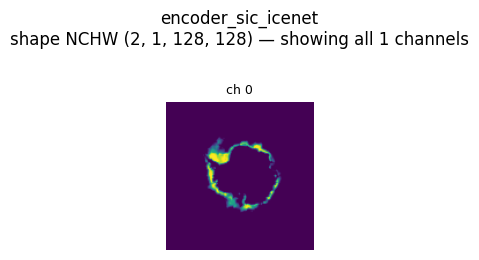

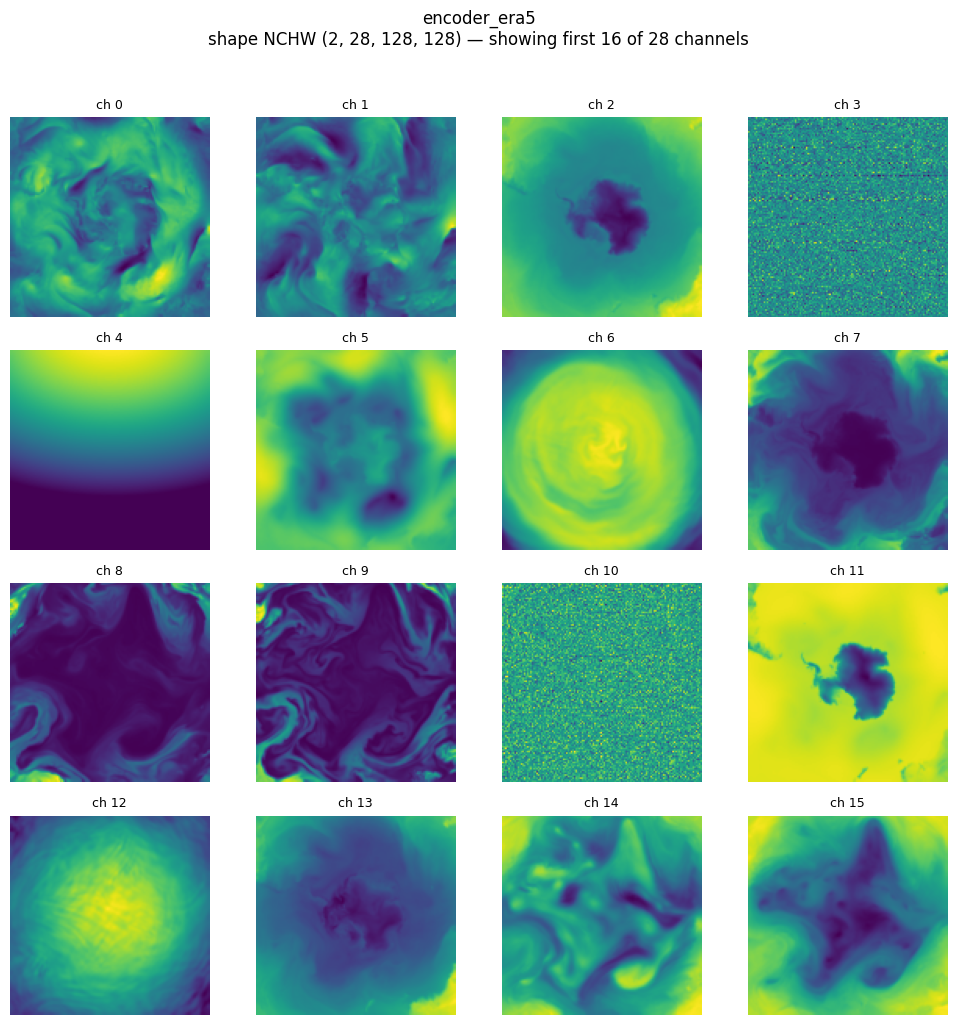

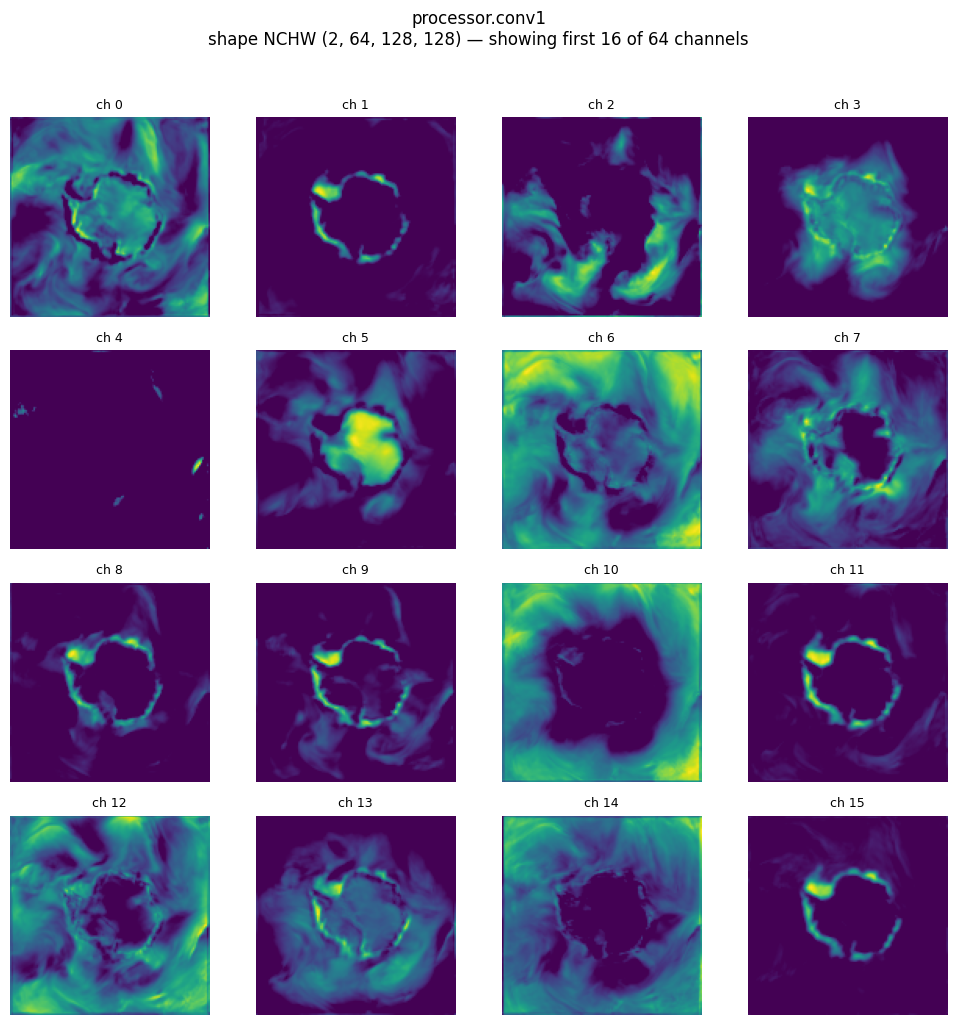

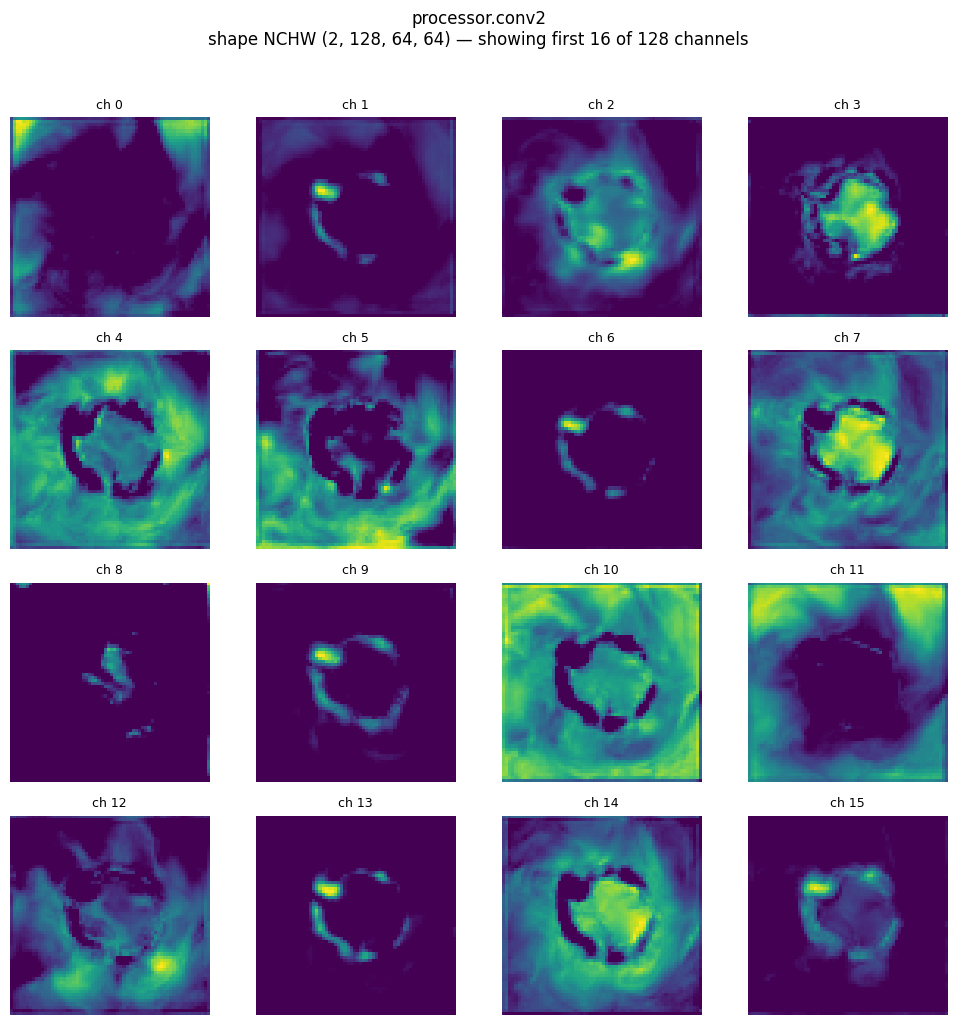

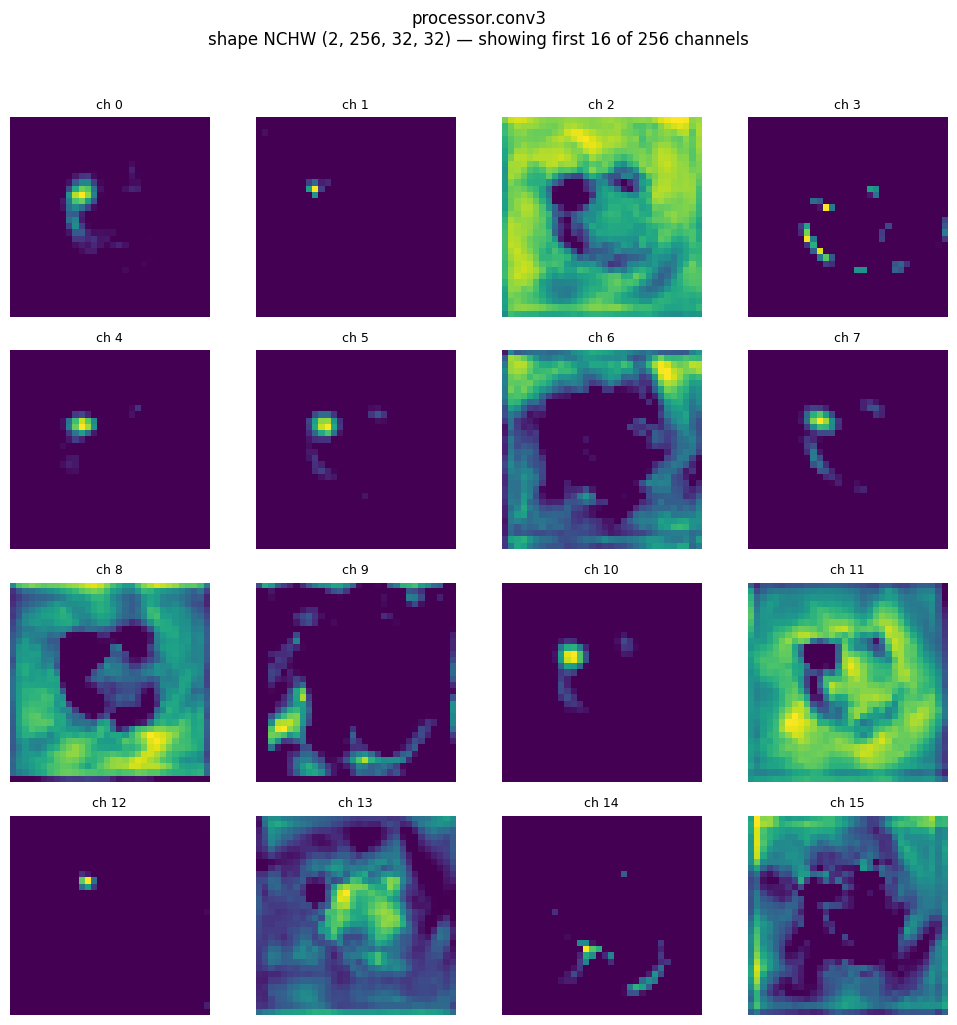

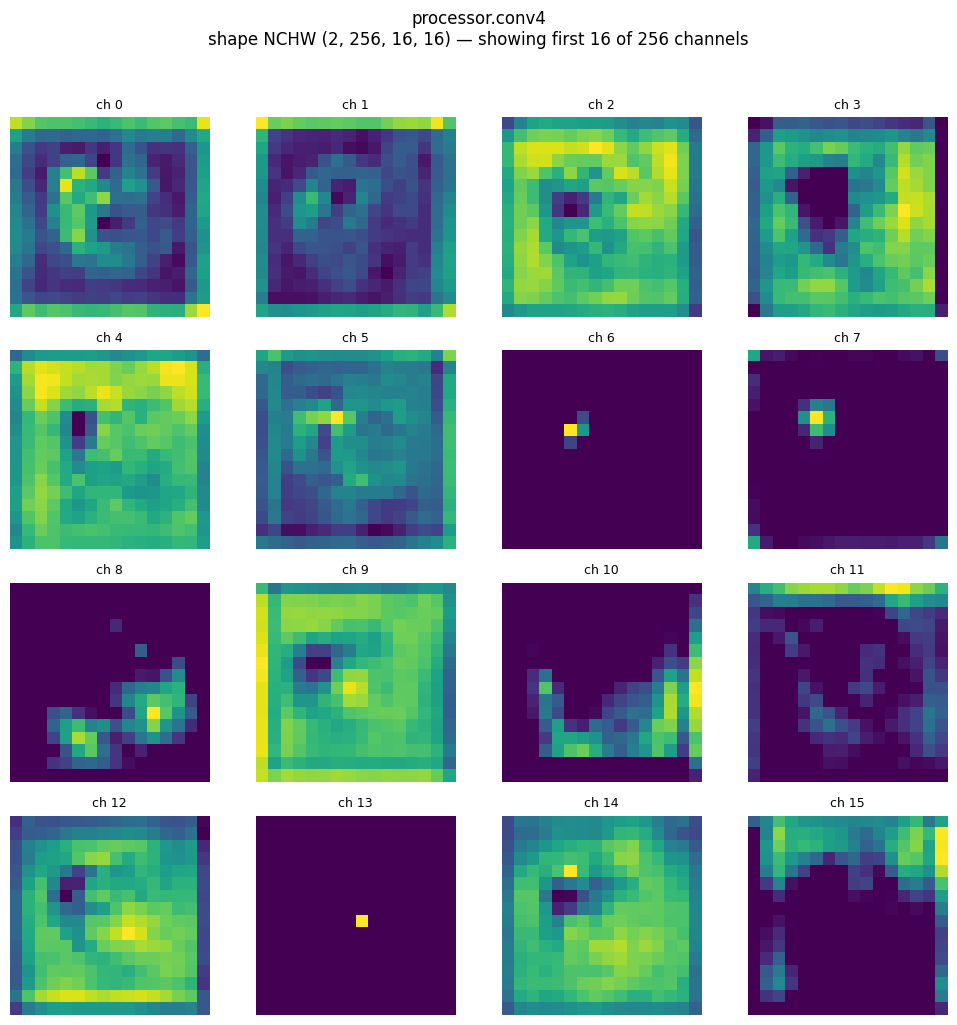

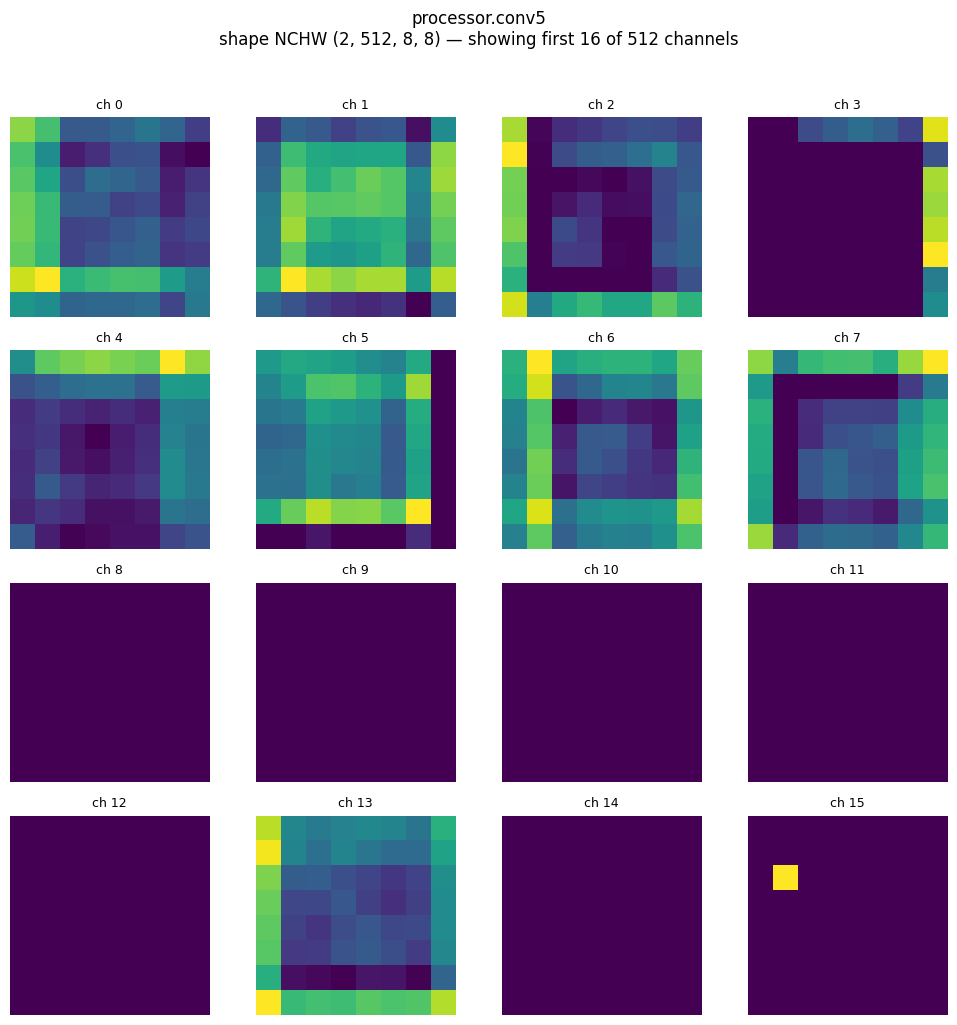

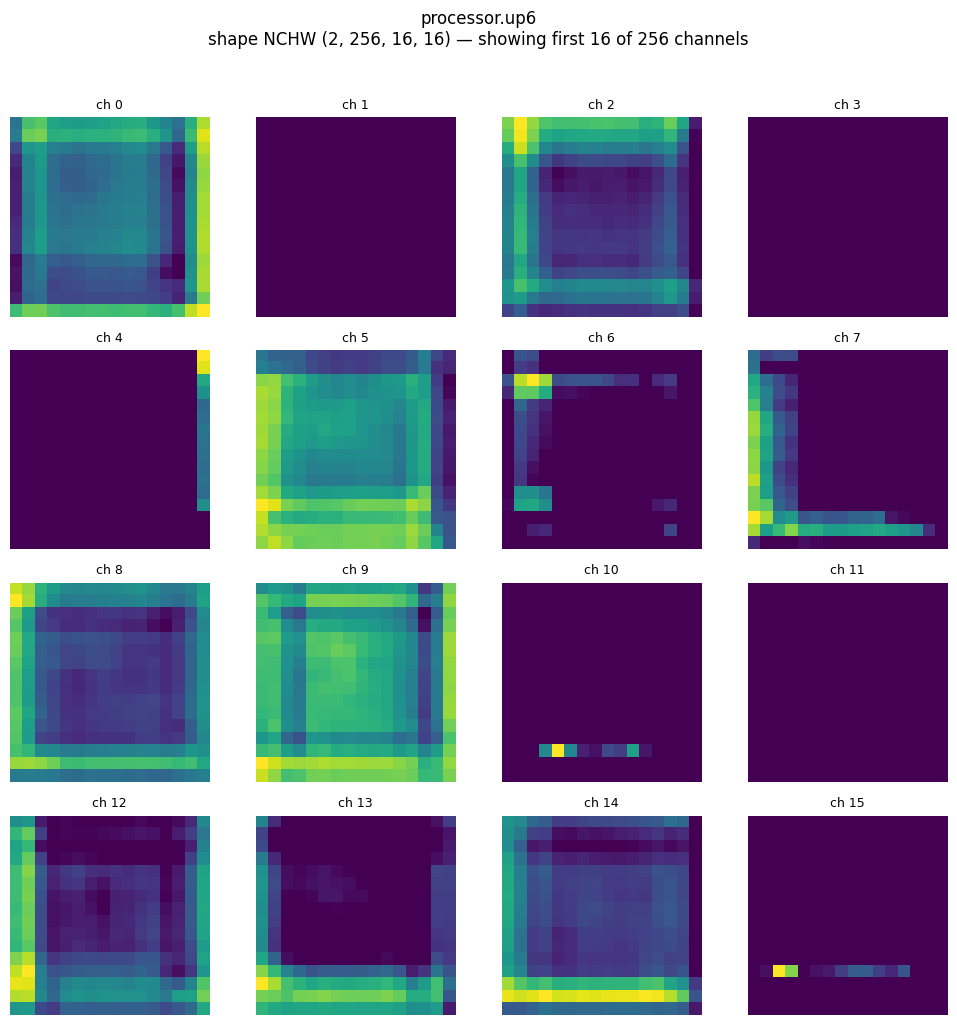

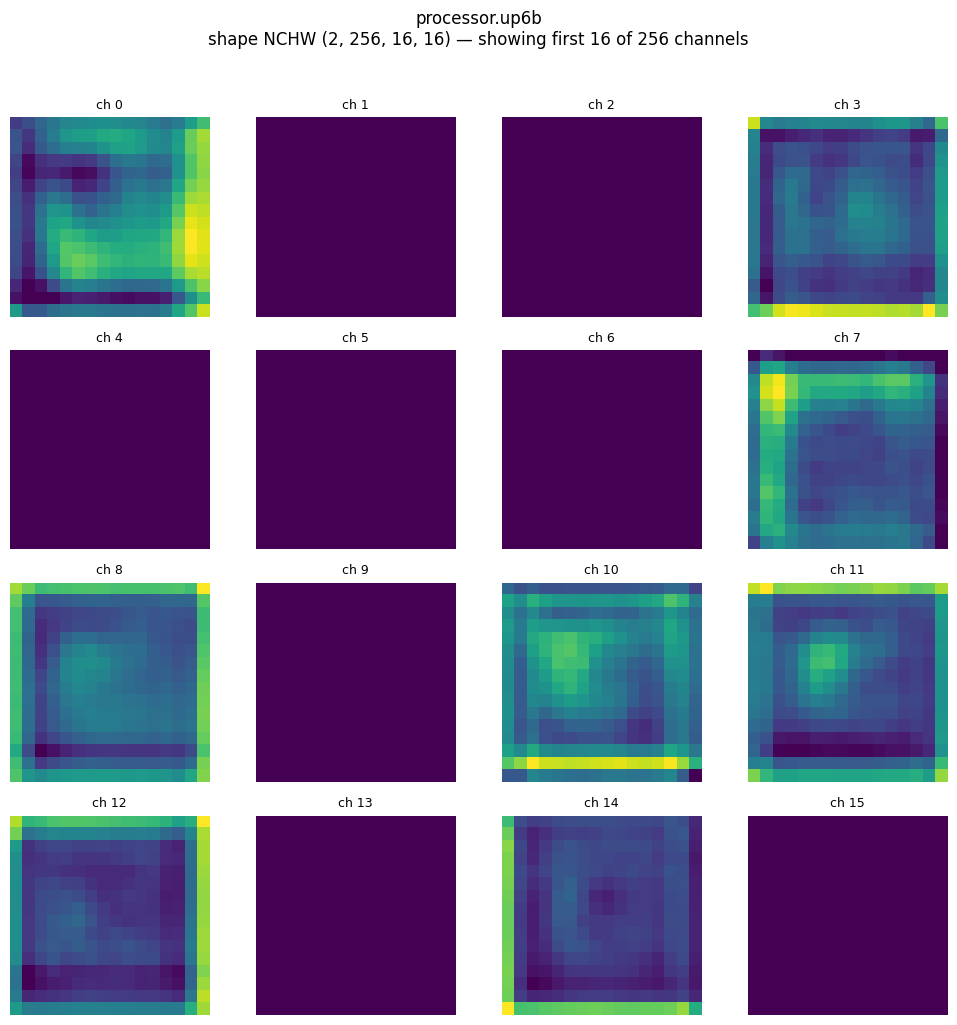

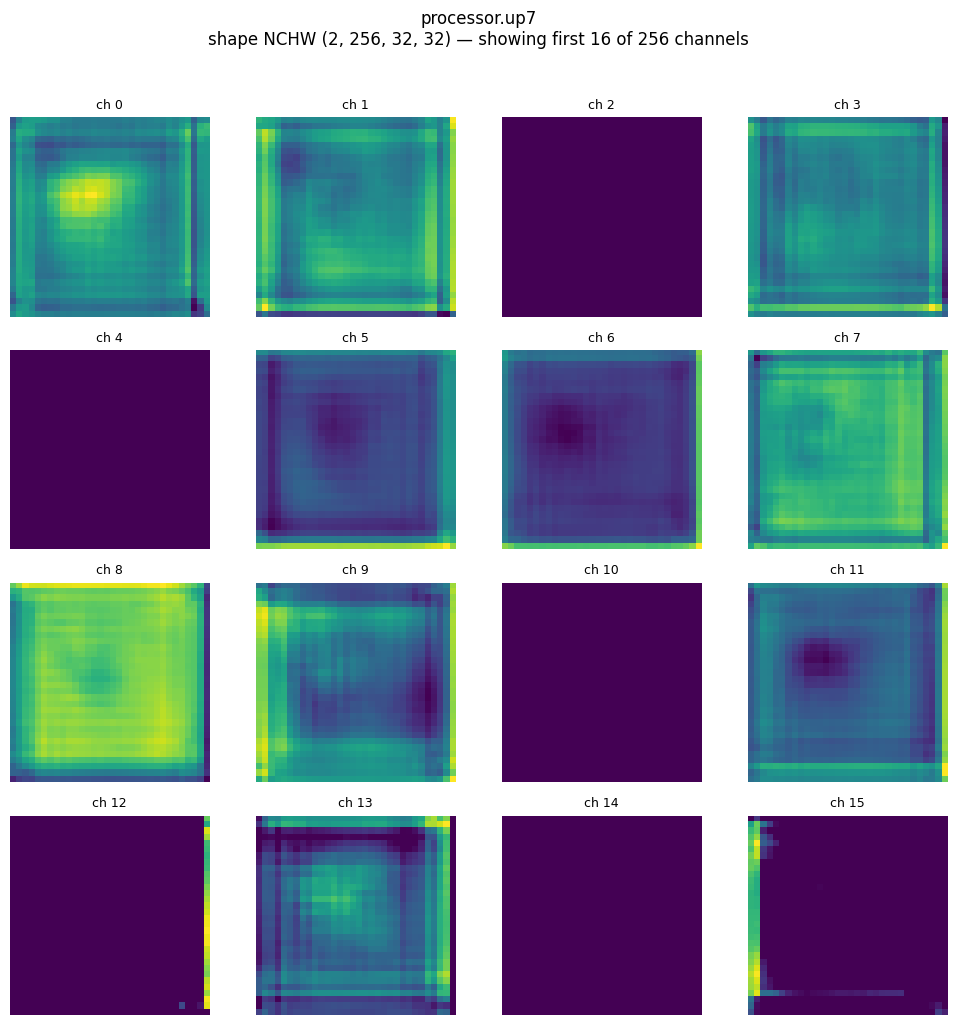

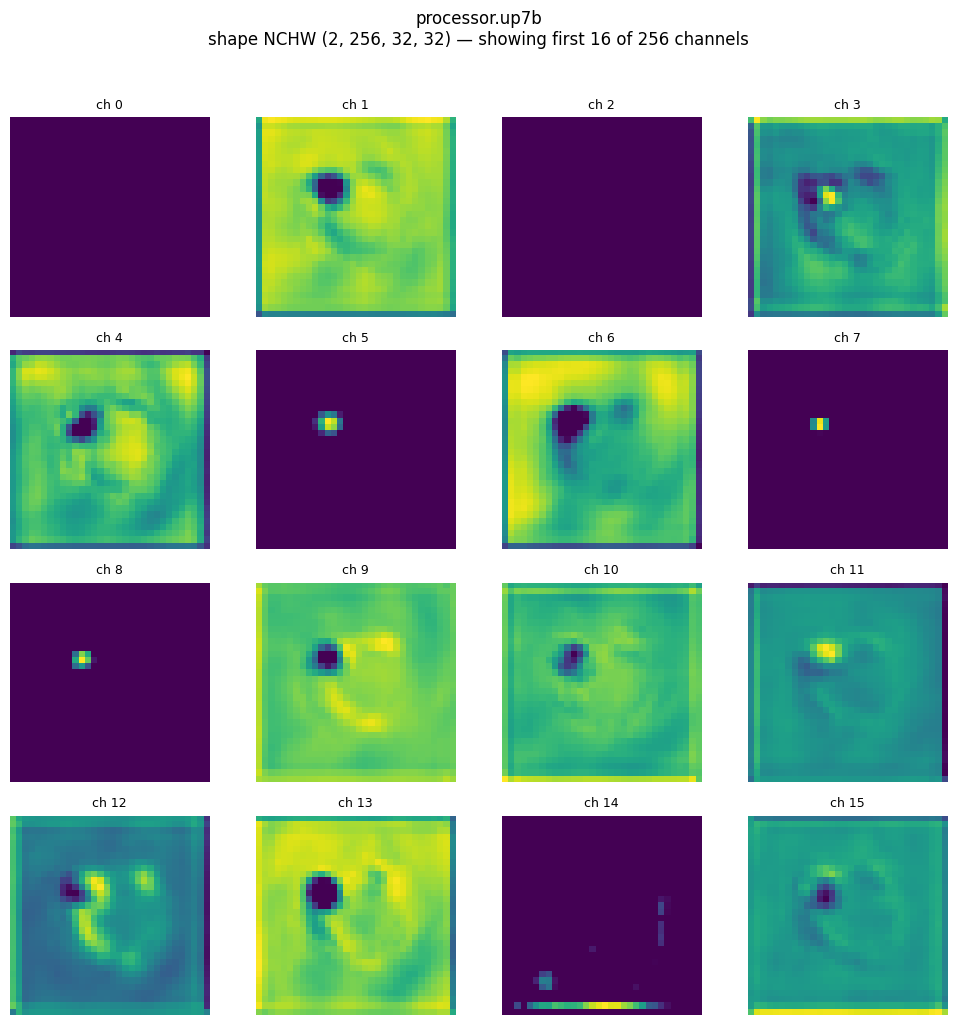

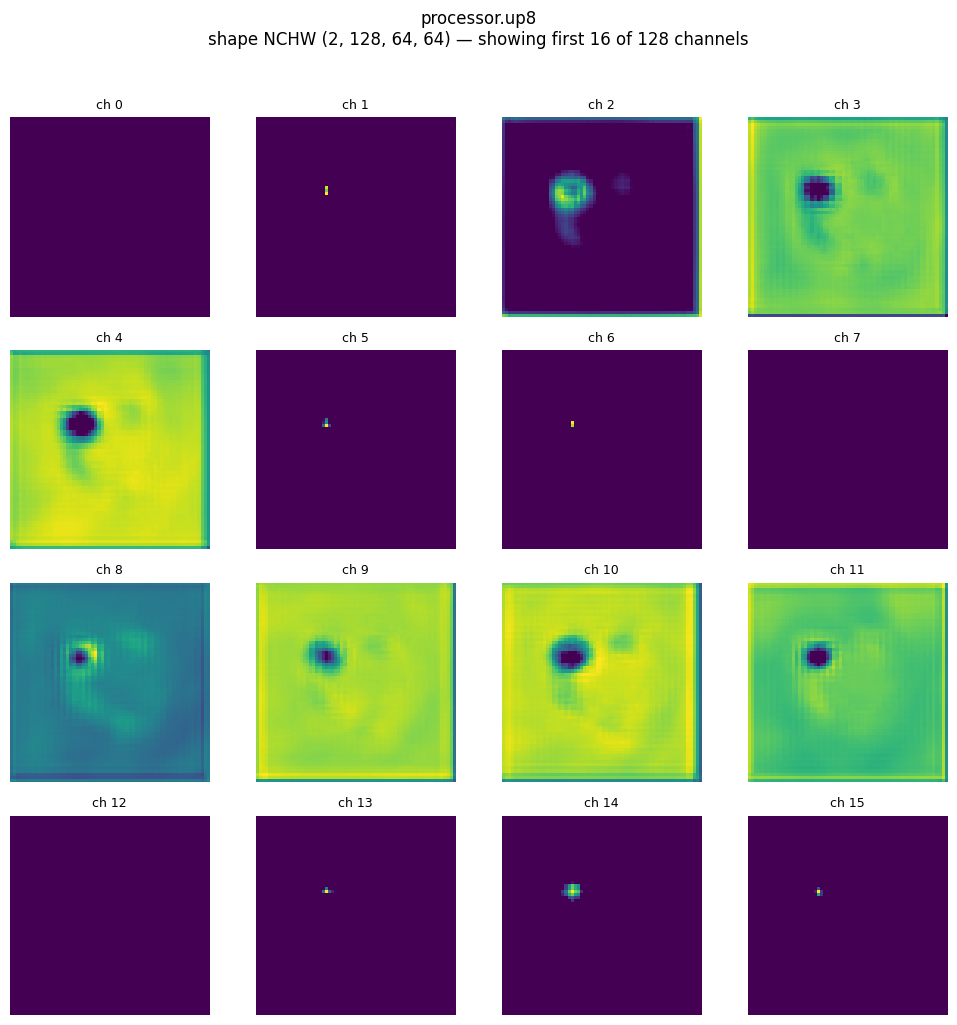

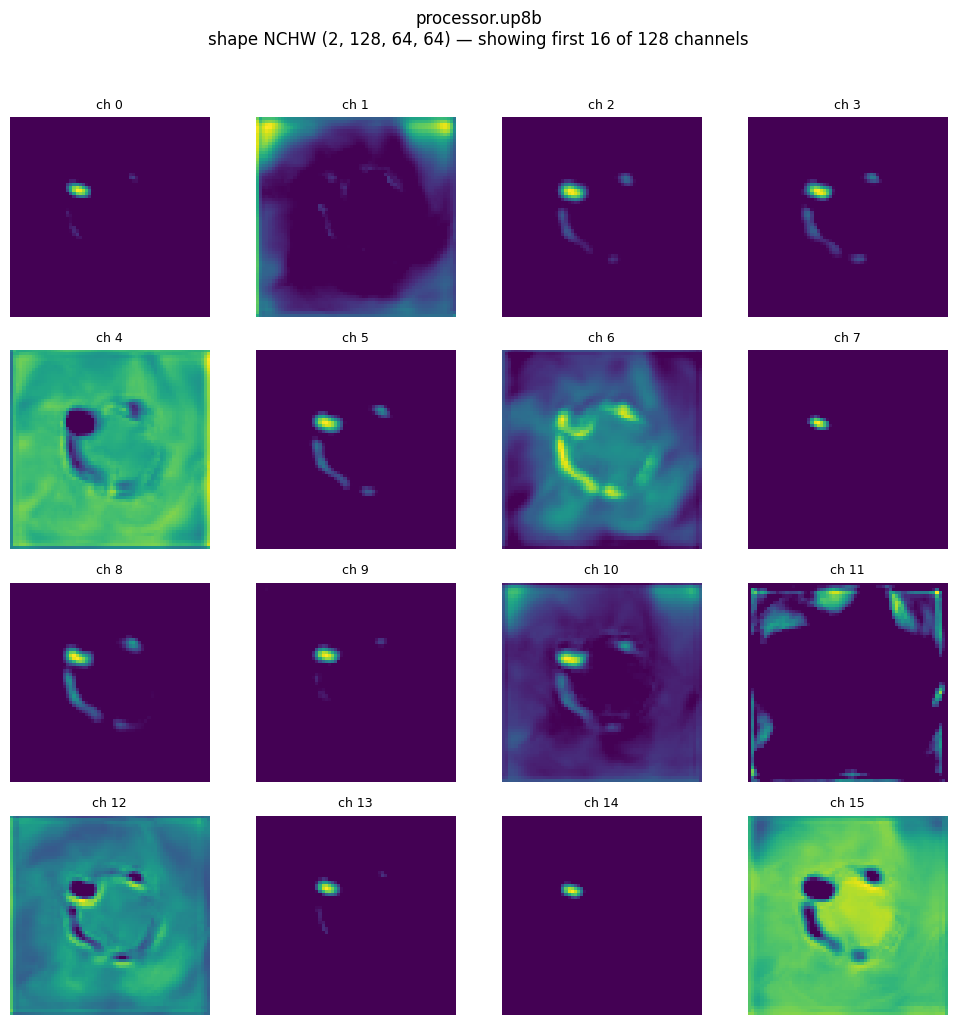

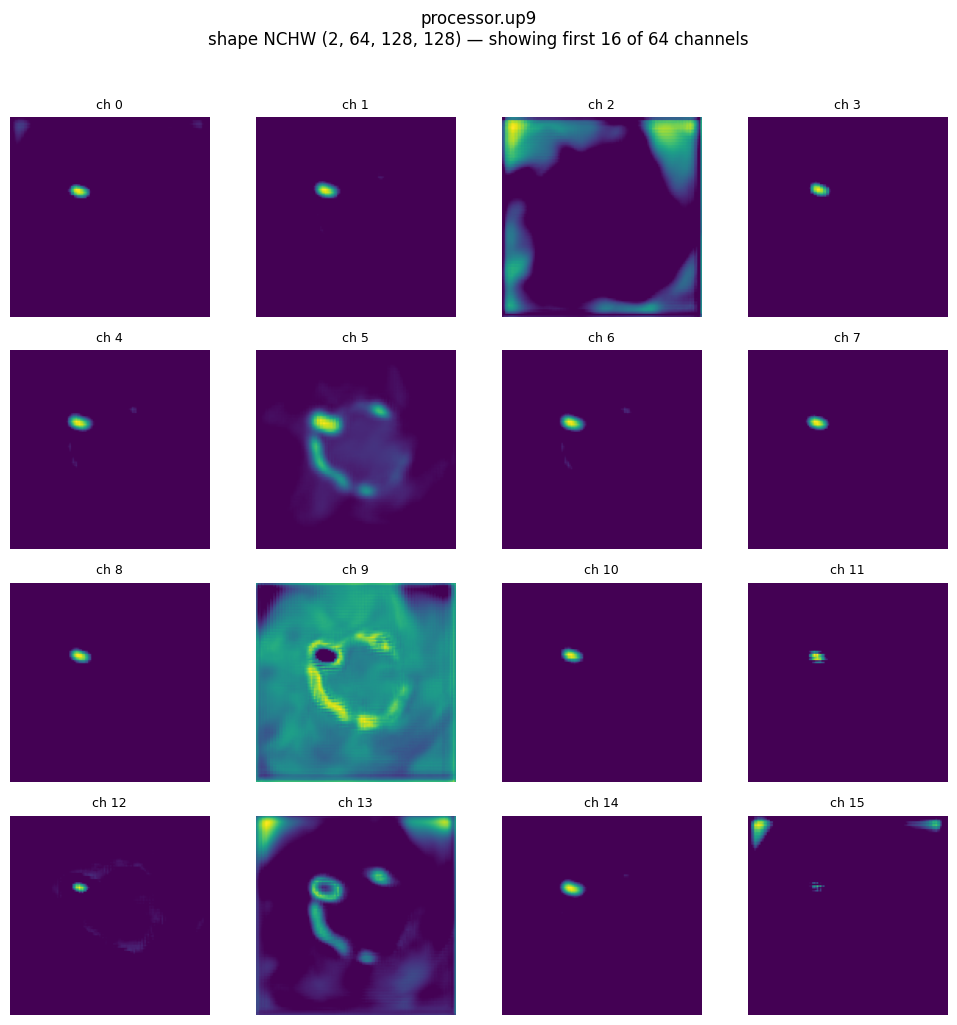

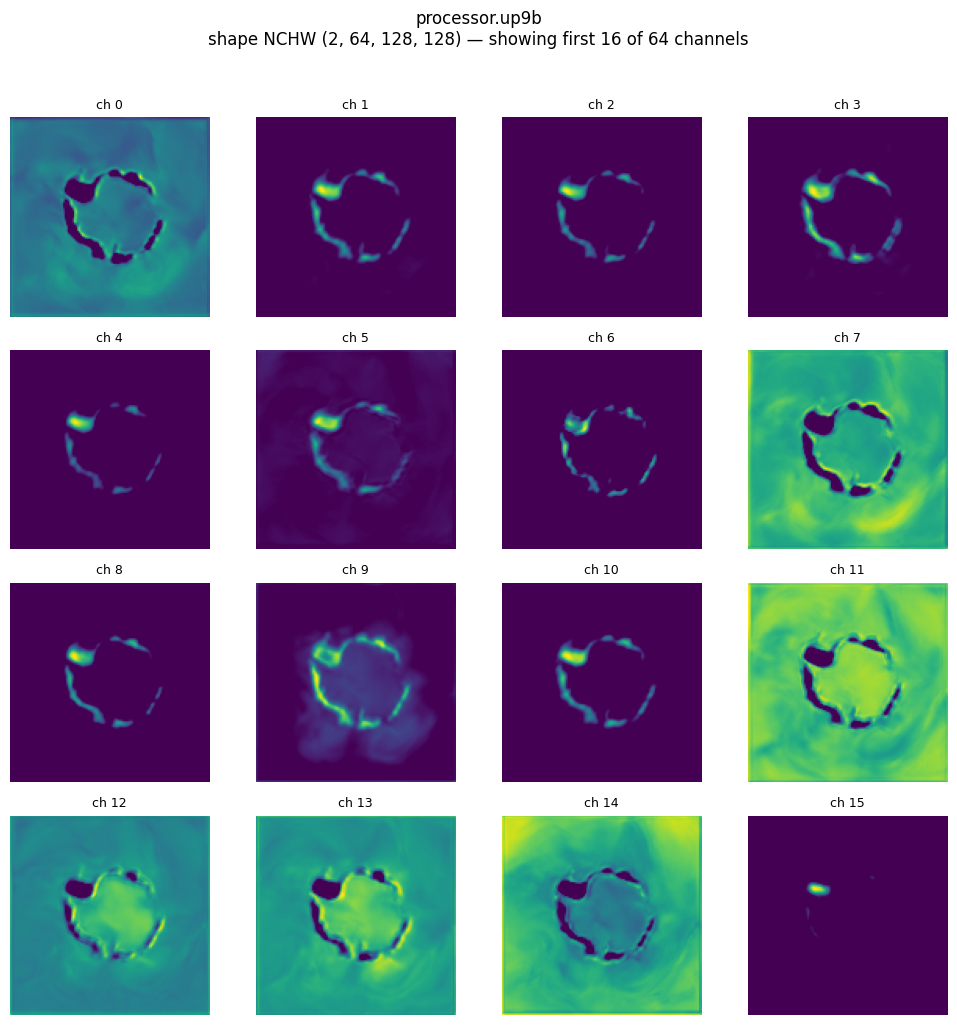

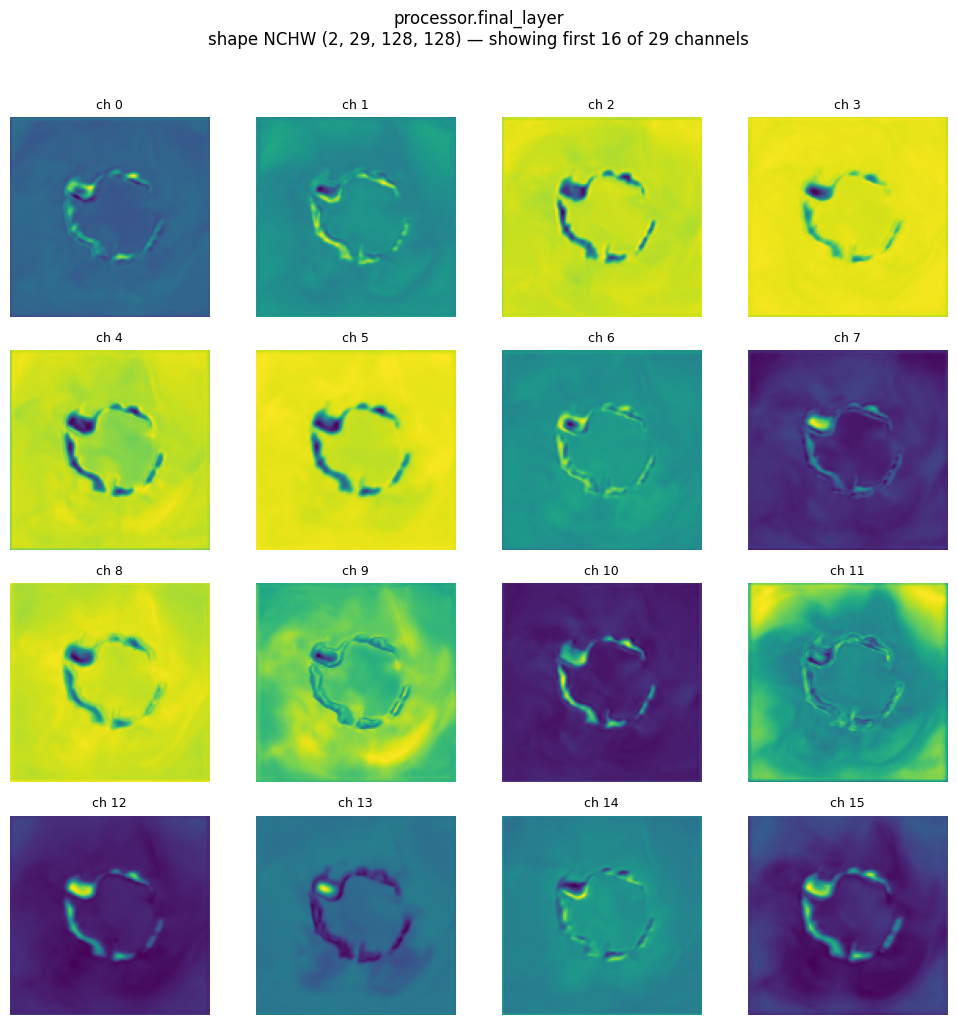

In [9]:
import matplotlib.pyplot as plt

BATCH_ELEMENT = 0
MAX_CHANNELS_PER_LAYER = 16
TILE_COLS = 4


def plot_feature_maps(title: str, nchw: torch.Tensor) -> None:
    chw = nchw[BATCH_ELEMENT].float().cpu()
    n_channels = min(MAX_CHANNELS_PER_LAYER, chw.shape[0])
    cols = min(TILE_COLS, n_channels)
    rows = (n_channels + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.5 * rows))
    flat_axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for idx in range(n_channels):
        flat_axes[idx].imshow(chw[idx].numpy(), cmap="viridis")
        flat_axes[idx].set_title(f"ch {idx}", fontsize=9)
        flat_axes[idx].axis("off")
    for idx in range(n_channels, len(flat_axes)):
        flat_axes[idx].axis("off")
    channel_note = (
        f"all {chw.shape[0]}"
        if n_channels == chw.shape[0]
        else f"first {n_channels} of {chw.shape[0]}"
    )
    fig.suptitle(
        f"{title}\nshape NCHW {tuple(nchw.shape)} — showing {channel_note} channels",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

payload = torch.load(batch_files[BATCH_ELEMENT], map_location="cpu", weights_only=False)
for name, tensor in payload["activations"].items():
    plot_feature_maps(name, tensor)


## 5. Reading the plots

- **`encoder_era5`** channels should look like coarse maps of the 28 atmospheric variables. If early UNet layers (`conv1`, `maxpool1`) show structure consistent with those ERA5 fields — and not just SIC contours — that is evidence the model is using ERA5.
- **`conv5` (bottleneck)** reduces the full Arctic domain to an 8×8 grid of 512 channels. Repeated patterns across channels often indicate low effective rank; varied, spatially structured channels suggest the bottleneck is encoding distinct atmospheric/ice regimes.
- Differences between two batches with similar SIC but different ERA5 regimes give the cleanest signal — run this notebook twice against different test batches (or override `++predict.dataset_group` / similar via `HYDRA_OVERRIDES`) and compare.

To inspect another batch, change the index in the load cell (`batch_files[0]` → `batch_files[k]`) and re-run the plotting cell.